# Trabajo Final — Machine Learning
## Predicción de la demanda horaria de energía eléctrica a partir de variables climáticas y de calendario

**Integrantes:** Sofía Castañeda Arias · James Jair Olarte López
**Dataset:** `Energy_Demand.csv` (2.000 registros, 19 variables)
**Metodología:** CRISP-DM

Este cuaderno desarrolla las fases **3. Preparación de datos**, **4. Modelamiento y evaluación** y **5. Despliegue**.
Las fases 1 y 2 (entendimiento del negocio y de los datos) están en el documento del trabajo.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score)

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')
SEMILLA = 42
print('scikit-learn', sklearn.__version__)

scikit-learn 1.9.1


### Carga del dataset
En Colab, si el archivo no está en la sesión, se abre un diálogo para subir `Energy_Demand.csv`.

In [2]:
RUTAS = ['Energy_Demand.csv', 'datasets/Energy_Demand.csv']
ruta = next((r for r in RUTAS if os.path.exists(r)), None)
if ruta is None:
    from google.colab import files
    files.upload()
    ruta = 'Energy_Demand.csv'

df_raw = pd.read_csv(ruta)
print(df_raw.shape)
df_raw.head()

(2000, 19)


,RecordID,FullName,Phone,ZodiacSign,FavoriteColor,Hobby,DateTime,Temperature,Temperature_F,Humidity,IsHoliday,DayOfWeek,Hour,Month,PreviousDemand,Season,Country,EnergyDemand,PeakHourFlag
0,REC00001,Elena Smith,"3,223,816,476.00",Libra,Purple,Travel,01/01/2023 00:00,23.63,74.53,70.97,0,1,6.00,2,NaN,Winter,Colombia,845.62,0
1,REC00002,David Anderson,"3,554,367,178.00",Scorpio,Gray,Music,01/01/2023 01:00,12.14,53.85,68.08,0,3,19.00,12,951.46,Winter,Colombia,915.25,1
2,REC00003,Elena Moore,"3,438,580,972.00",Leo,Purple,Dancing,01/01/2023 02:00,20.47,68.85,70.74,0,5,14.00,3,821.52,Spring,Colombia,797.22,0
3,REC00004,Richard Martinez,"3,749,876,519.00",Gemini,Gray,Cooking,01/01/2023 03:00,23.57,74.43,95.92,0,6,10.00,4,859.74,Spring,Colombia,857.63,0
4,REC00005,Michael Garcia,"3,611,289,374.00",Virgo,Pink,Hiking,01/01/2023 04:00,17.26,63.07,92.78,0,1,7.00,7,NaN,NaN,Colombia,871.88,0


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RecordID        2000 non-null   str    
 1   FullName        2000 non-null   str    
 2   Phone           2000 non-null   float64
 3   ZodiacSign      2000 non-null   str    
 4   FavoriteColor   2000 non-null   str    
 5   Hobby           2000 non-null   str    
 6   DateTime        2000 non-null   str    
 7   Temperature     1808 non-null   float64
 8   Temperature_F   2000 non-null   float64
 9   Humidity        1800 non-null   float64
 10  IsHoliday       2000 non-null   int64  
 11  DayOfWeek       2000 non-null   int64  
 12  Hour            2000 non-null   float64
 13  Month           2000 non-null   int64  
 14  PreviousDemand  1800 non-null   float64
 15  Season          1800 non-null   str    
 16  Country         2000 non-null   str    
 17  EnergyDemand    2000 non-null   float64
 18 

---
# 3. PREPARACIÓN DE DATOS

## 3.1 Selección de variables desde el conocimiento del negocio

Siguiendo lo concluido en la fase 2, se descartan:

| Variable | Motivo |
|---|---|
| RecordID, FullName, Phone, ZodiacSign, FavoriteColor, Hobby | Ruido / identificadores / datos personales |
| PeakHourFlag | **Fuga de información**: se construyó a partir de la demanda |
| Season | No describe un fenómeno real en Colombia (país sin estaciones) |
| Hour, DayOfWeek, Month (originales) | Corruptas: no coinciden con `DateTime`. Se reconstruyen desde `DateTime` |
| Temperature_F | Redundante con `Temperature`. Se usa **solo** para recuperar valores de `Temperature` y luego se elimina |
| Country | Casi constante. Se usa para filtrar registros de otros países y luego se elimina |

In [4]:
df = df_raw.copy()

# DateTime viene como texto -> datetime
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H:%M')

# Comprobación: las columnas de calendario originales NO coinciden con DateTime
print('Coincidencia Hour      :', round((df['Hour'] == df['DateTime'].dt.hour).mean() * 100, 1), '%')
print('Coincidencia DayOfWeek :', round((df['DayOfWeek'] == df['DateTime'].dt.dayofweek).mean() * 100, 1), '%')
print('Coincidencia Month     :', round((df['Month'] == df['DateTime'].dt.month).mean() * 100, 1), '%')

ruido = ['RecordID', 'FullName', 'Phone', 'ZodiacSign', 'FavoriteColor', 'Hobby']
df = df.drop(columns=ruido + ['PeakHourFlag', 'Season', 'Hour', 'DayOfWeek', 'Month'])
df = df.sort_values('DateTime').reset_index(drop=True)
df.head()

Coincidencia Hour      : 4.1 %
Coincidencia DayOfWeek : 13.4 %
Coincidencia Month     : 8.0 %


,DateTime,Temperature,Temperature_F,Humidity,IsHoliday,PreviousDemand,Country,EnergyDemand
0,2023-01-01 00:00:00,23.63,74.53,70.97,0,NaN,Colombia,845.62
1,2023-01-01 01:00:00,12.14,53.85,68.08,0,951.46,Colombia,915.25
2,2023-01-01 02:00:00,20.47,68.85,70.74,0,821.52,Colombia,797.22
3,2023-01-01 03:00:00,23.57,74.43,95.92,0,859.74,Colombia,857.63
4,2023-01-01 04:00:00,17.26,63.07,92.78,0,NaN,Colombia,871.88


## 3.2 Descripción estadística

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DateTime,2000,2023-02-11 15:30:00,2023-01-01 00:00:00,2023-01-21 19:45:00,2023-02-11 15:30:00,2023-03-04 11:15:00,2023-03-25 07:00:00,NaN
Temperature,"1,808.00",19.78,-40.00,14.24,19.85,25.13,80.00,8.87
Temperature_F,"2,000.00",67.58,22.26,57.63,67.89,77.43,114.70,14.51
Humidity,"1,800.00",59.55,16.51,49.35,59.39,70.11,100.00,15.17
IsHoliday,"2,000.00",0.07,0.00,0.00,0.00,0.00,1.00,0.26
PreviousDemand,"1,800.00",930.36,671.89,839.91,894.97,979.92,"1,873.06",143.55
EnergyDemand,"2,000.00",942.47,-100.00,840.73,892.94,979.65,"8,000.00",311.68


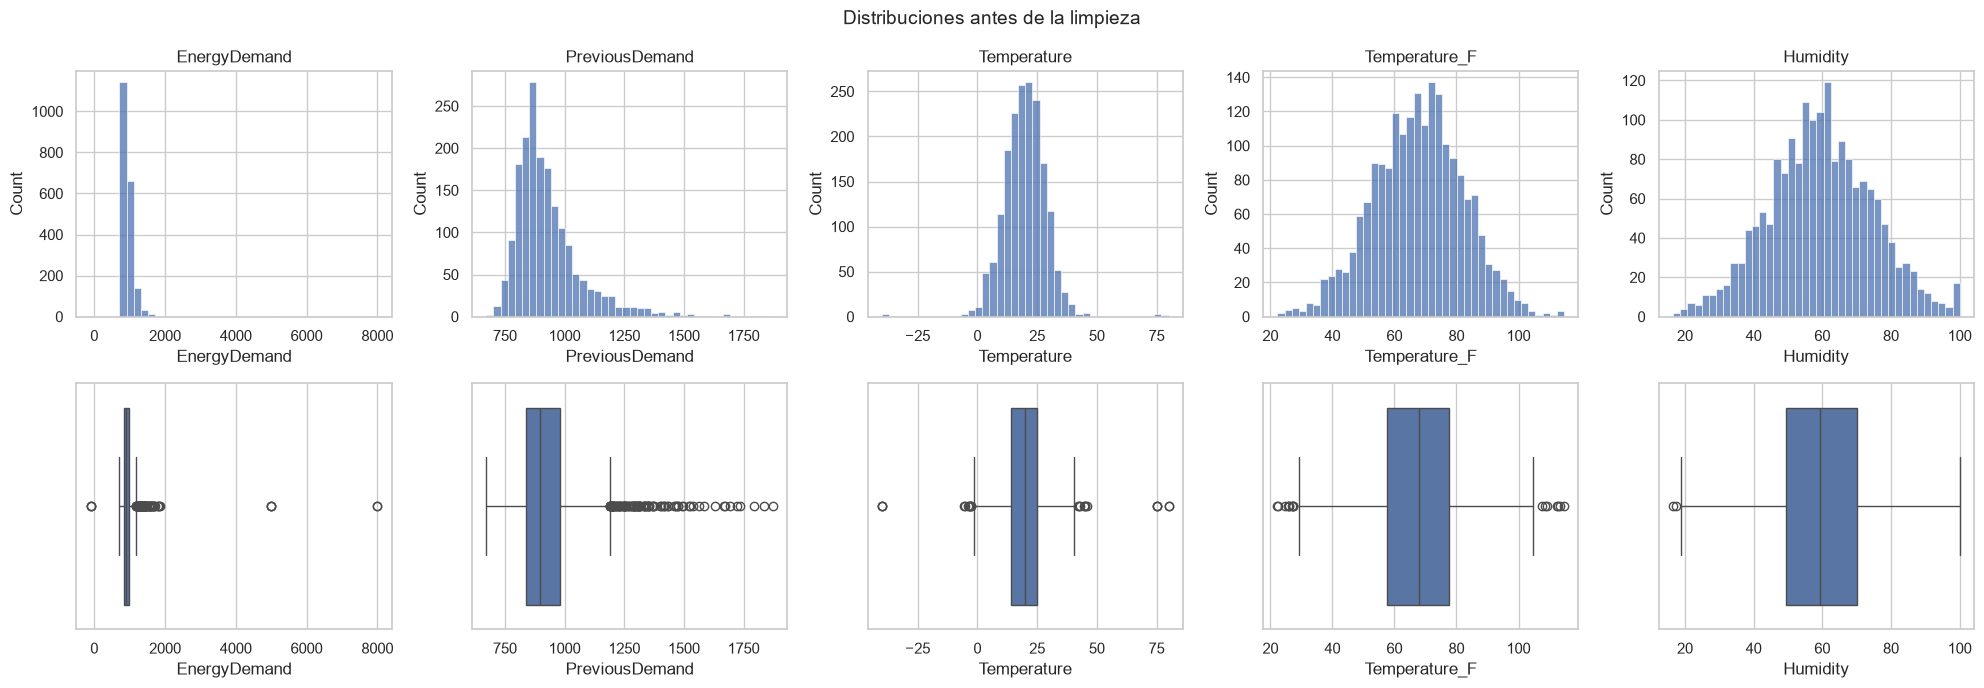

Nulos por variable:
DateTime            0
Temperature       192
Temperature_F       0
Humidity          200
IsHoliday           0
PreviousDemand    200
Country             0
EnergyDemand        0
dtype: int64

Country:
Country
Colombia    1952
Mexico        24
Peru          14
Chile         10
Name: count, dtype: int64


In [6]:
num_cols = ['EnergyDemand', 'PreviousDemand', 'Temperature', 'Temperature_F', 'Humidity']
fig, axes = plt.subplots(2, len(num_cols), figsize=(20, 7))
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), bins=40, ax=axes[0, i]); axes[0, i].set_title(c)
    sns.boxplot(x=df[c].dropna(), ax=axes[1, i])
plt.suptitle('Distribuciones antes de la limpieza', fontsize=14)
plt.tight_layout(); plt.show()

print('Nulos por variable:')
print(df.isnull().sum())
print('\nCountry:'); print(df['Country'].value_counts())

Se observan los problemas ya identificados en la fase 2: valores imposibles en `EnergyDemand` (−100, 5.000, 8.000 MW)
y en `Temperature` (−40, 75, 80 °C), además de nulos en `Temperature`, `Humidity` y `PreviousDemand`.

## 3.3 Limpieza de atípicos

Se aplican las **reglas de calidad** definidas en la fase 2:

| Variable | Rango válido | Tratamiento si está fuera de rango |
|---|---|---|
| EnergyDemand | 300 – 2.000 MW | **Borrar el registro**: es la variable objetivo, imputarla sería inventar la respuesta |
| PreviousDemand | 300 – 2.000 MW | Se marca como nulo |
| Temperature | −5 – 45 °C | Se recupera desde `Temperature_F` |
| Humidity | 0 – 100 % | Se marca como nulo |
| Country | Colombia | **Borrar el registro**: el ejercicio es de un solo sistema eléctrico |

In [7]:
n0 = len(df)

# 1) Variable objetivo fuera de rango -> se elimina el registro
fuera_obj = ~df['EnergyDemand'].between(300, 2000)
print('EnergyDemand fuera de rango:', fuera_obj.sum(), '->', sorted(df.loc[fuera_obj, 'EnergyDemand'].unique()))
df = df[~fuera_obj]

# 2) Registros de otros países -> se eliminan
otros = df['Country'] != 'Colombia'
print('Registros de otros países  :', otros.sum())
df = df[~otros].drop(columns='Country')

# 3) PreviousDemand y Humidity fuera de rango -> nulo
df.loc[~df['PreviousDemand'].between(300, 2000), 'PreviousDemand'] = np.nan  # (los NaN siguen NaN)
df.loc[~df['Humidity'].between(0, 100), 'Humidity'] = np.nan

# 4) Temperature: recuperar desde Fahrenheit
temp_desde_f = (df['Temperature_F'] - 32) * 5 / 9
temp_desde_f = temp_desde_f.where(temp_desde_f.between(-5, 45))   # el F también debe ser válido
temp_mala = ~df['Temperature'].between(-5, 45)                      # incluye nulos e imposibles
print('Temperature nula o imposible:', temp_mala.sum())
df.loc[temp_mala, 'Temperature'] = temp_desde_f[temp_mala]
print('Temperature aún sin dato     :', df['Temperature'].isna().sum())
df = df.drop(columns='Temperature_F')

print(f'\nRegistros: {n0} -> {len(df)}')

EnergyDemand fuera de rango: 8 -> [np.float64(-100.0), np.float64(5000.0), np.float64(8000.0)]
Registros de otros países  : 48
Temperature nula o imposible: 202
Temperature aún sin dato     : 4

Registros: 2000 -> 1944


## 3.4 Limpieza de nulos

In [8]:
print(df.isnull().sum())

DateTime            0
Temperature         4
Humidity          199
IsHoliday           0
PreviousDemand    196
EnergyDemand        0
dtype: int64


Decisiones:

* **Temperature**: ya se recuperó casi en su totalidad desde `Temperature_F`. Lo que quede se imputa con la **mediana**.
* **Humidity**: se imputa con la **mediana**. Tiene correlación muy baja con el objetivo, así que la imputación no distorsiona el modelo.
* **PreviousDemand**: se **eliminan** esos registros. Es la variable más importante (correlación 0,99 con el objetivo);
  imputarla con la mediana metería un error del orden del 10 % justo en el insumo principal.
  Además, en producción esta variable **siempre** está disponible (es la medición de la hora que acaba de pasar),
  así que el modelo no necesita aprender a funcionar sin ella.

> La imputación por mediana se hace **dentro del pipeline** del modelo, de modo que la mediana se calcula solo
> con los datos de entrenamiento y no hay fuga de información desde el set de prueba.

In [9]:
n_antes = len(df)
df = df.dropna(subset=['PreviousDemand']).reset_index(drop=True)
print(f'Registros eliminados por PreviousDemand nulo: {n_antes - len(df)}')
print(f'Dataset final: {len(df)} registros ({len(df)/len(df_raw)*100:.1f} % del original)')

Registros eliminados por PreviousDemand nulo: 196
Dataset final: 1748 registros (87.4 % del original)


## 3.5 Creación de nuevas variables

A partir de `DateTime` se reconstruyen las variables de calendario y se crean nuevas:

| Variable | Construcción | Por qué |
|---|---|---|
| Hour | hora de `DateTime` | Reemplaza la columna corrompida |
| Hour_sin, Hour_cos | seno y coseno de 2π·hora/24 | La hora es **cíclica**: 23 h y 0 h están juntas. Como número lineal parecerían lejanas |
| DayOfWeek | día de la semana de `DateTime` | Reemplaza la columna corrompida. Se codifica con **One Hot Encoding** |
| IsWeekend | 1 si sábado o domingo | El consumo industrial cae los fines de semana |
| Month | mes de `DateTime` (1–3) | Se codifica con **One Hot Encoding** |

El One Hot Encoding se aplica dentro del pipeline (`OneHotEncoder`) para que el modelo desplegado reciba los mismos datos crudos.

In [10]:
def crear_variables(d):
    """Variables de calendario a partir de DateTime. Se usa igual en entrenamiento y en el despliegue."""
    d = d.copy()
    hora = d['DateTime'].dt.hour
    d['Hour'] = hora
    d['Hour_sin'] = np.sin(2 * np.pi * hora / 24)
    d['Hour_cos'] = np.cos(2 * np.pi * hora / 24)
    d['DayOfWeek'] = d['DateTime'].dt.dayofweek
    d['IsWeekend'] = (d['DayOfWeek'] >= 5).astype(int)
    d['Month'] = d['DateTime'].dt.month
    return d

df = crear_variables(df)
df.head()

,DateTime,Temperature,Humidity,IsHoliday,PreviousDemand,EnergyDemand,Hour,Hour_sin,Hour_cos,DayOfWeek,IsWeekend,Month
0,2023-01-01 01:00:00,12.14,68.08,0,951.46,915.25,1,0.26,0.97,6,1,1
1,2023-01-01 02:00:00,20.47,70.74,0,821.52,797.22,2,0.50,0.87,6,1,1
2,2023-01-01 03:00:00,23.57,95.92,0,859.74,857.63,3,0.71,0.71,6,1,1
3,2023-01-01 05:00:00,21.36,49.70,0,868.08,898.65,5,0.97,0.26,6,1,1
4,2023-01-01 06:00:00,12.30,84.36,0,850.70,844.48,6,1.00,0.00,6,1,1


## 3.6 Análisis de relaciones
### Análisis lineal (correlación de Pearson)

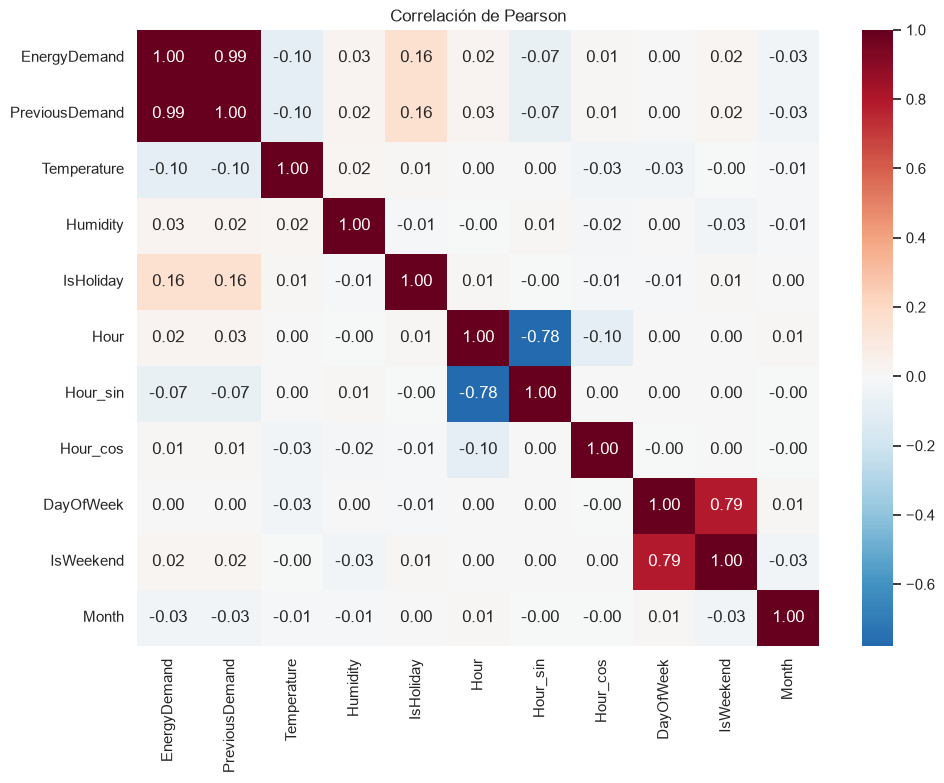

PreviousDemand    0.99
IsHoliday         0.16
Temperature      -0.10
Hour_sin         -0.07
Month            -0.03
Humidity          0.03
Hour              0.02
IsWeekend         0.02
Hour_cos          0.01
DayOfWeek         0.00
Name: EnergyDemand, dtype: float64

In [11]:
cols_rel = ['EnergyDemand', 'PreviousDemand', 'Temperature', 'Humidity', 'IsHoliday',
            'Hour', 'Hour_sin', 'Hour_cos', 'DayOfWeek', 'IsWeekend', 'Month']
corr = df[cols_rel].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlación de Pearson'); plt.show()

corr['EnergyDemand'].drop('EnergyDemand').sort_values(key=abs, ascending=False)

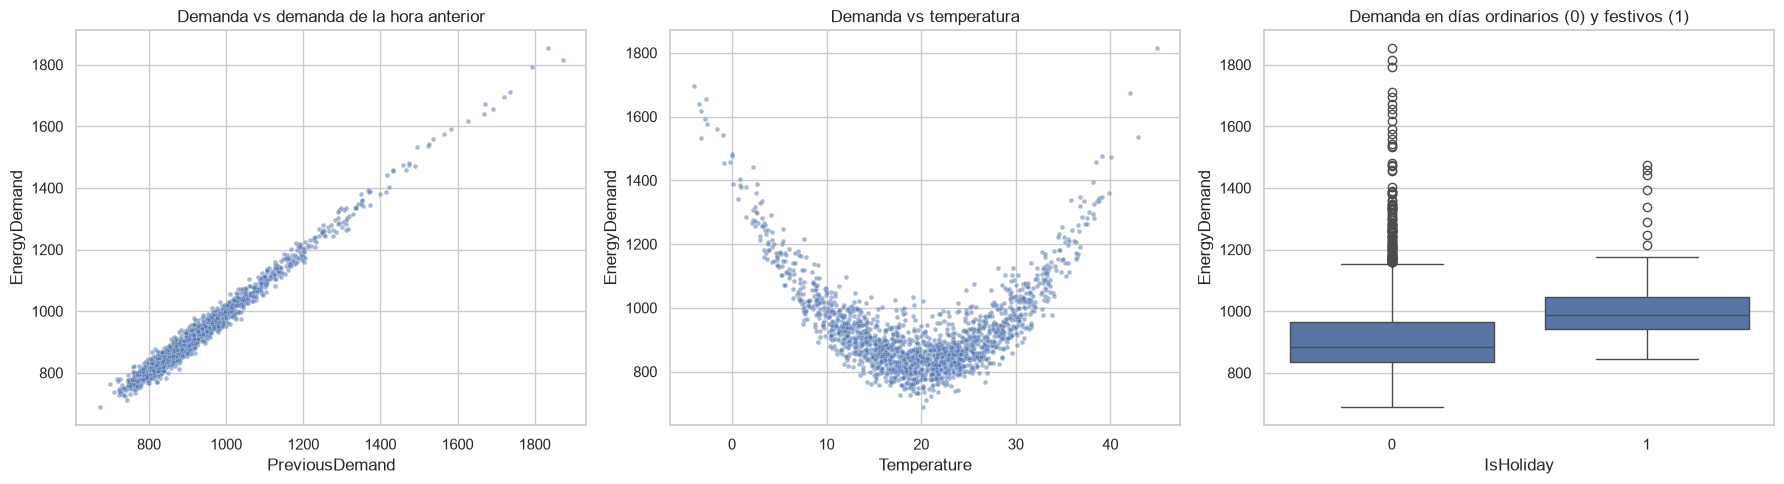

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x='PreviousDemand', y='EnergyDemand', s=12, alpha=.5, ax=axes[0])
axes[0].set_title('Demanda vs demanda de la hora anterior')
sns.scatterplot(data=df, x='Temperature', y='EnergyDemand', s=12, alpha=.5, ax=axes[1])
axes[1].set_title('Demanda vs temperatura')
sns.boxplot(data=df, x='IsHoliday', y='EnergyDemand', ax=axes[2])
axes[2].set_title('Demanda en días ordinarios (0) y festivos (1)')
plt.tight_layout(); plt.show()

### Análisis no lineal (información mutua)
La correlación de Pearson solo detecta relaciones lineales. La **información mutua** mide cualquier tipo de dependencia
(0 = independientes). Se complementa con la correlación de **Spearman** (relaciones monótonas).

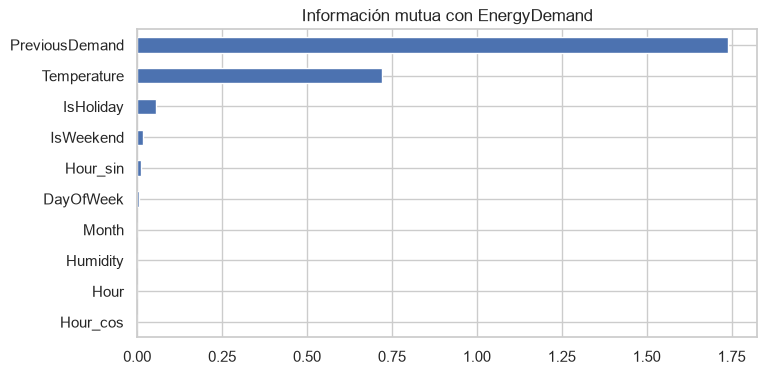

,Pearson,Spearman,Info. mutua
PreviousDemand,0.99,0.98,1.74
Temperature,-0.10,-0.06,0.72
IsHoliday,0.16,0.24,0.05
IsWeekend,0.02,0.00,0.02
Hour_sin,-0.07,-0.06,0.01
DayOfWeek,0.00,-0.01,0.01
Month,-0.03,-0.03,0.00
Humidity,0.03,0.02,0.00
Hour,0.02,0.02,0.00
Hour_cos,0.01,0.03,0.00


In [13]:
predictores = ['PreviousDemand', 'Temperature', 'Humidity', 'IsHoliday',
               'Hour', 'Hour_sin', 'Hour_cos', 'DayOfWeek', 'IsWeekend', 'Month']
X_mi = df[predictores].fillna(df[predictores].median())
mi = mutual_info_regression(X_mi, df['EnergyDemand'], random_state=SEMILLA)

relaciones = pd.DataFrame({
    'Pearson': df[predictores].corrwith(df['EnergyDemand']),
    'Spearman': df[predictores].corrwith(df['EnergyDemand'], method='spearman'),
    'Info. mutua': mi,
}, index=predictores).sort_values('Info. mutua', ascending=False)

relaciones['Info. mutua'].plot.barh(figsize=(8, 4), title='Información mutua con EnergyDemand').invert_yaxis()
plt.show()
relaciones

**Lectura:**
* `PreviousDemand` domina por completo, tanto en el análisis lineal como en el no lineal.
* **`Temperature` es el caso más interesante**: su correlación de Pearson es casi nula (≈ −0,10), pero su información mutua
  es la segunda más alta. La relación existe, solo que **no es lineal**: tiene forma de **U** (gráfica siguiente).
  Con frío la demanda sube por calefacción y con calor sube por aire acondicionado; el mínimo está entre 15 y 25 °C.
  Una recta no puede representar esa forma, por eso Pearson la "ve" como cero.
* `IsHoliday` tiene una relación débil pero consistente (los festivos tienen más demanda).
* Humedad y las variables de calendario muestran relaciones prácticamente nulas.

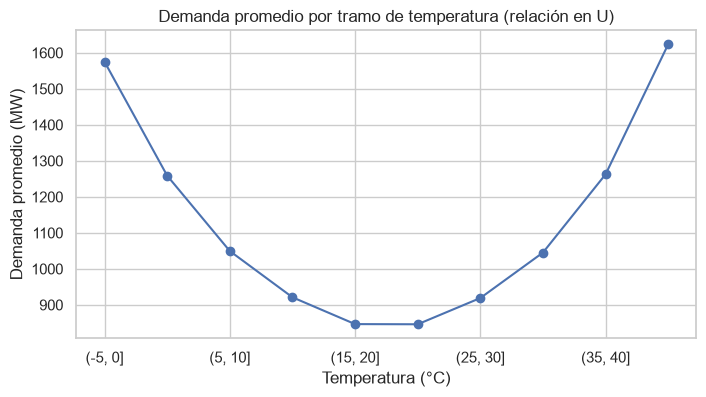

,mean,count
Temperature,,
"(-5, 0]","1,574.91",11
"(0, 5]","1,258.65",56
"(5, 10]","1,049.44",127
"(10, 15]",921.09,291
"(15, 20]",846.63,406
"(20, 25]",846.17,413
"(25, 30]",919.03,268
"(30, 35]","1,045.24",130
"(35, 40]","1,262.57",39


In [14]:
tramos = pd.cut(df['Temperature'], bins=range(-5, 50, 5))
curva = df.groupby(tramos, observed=True)['EnergyDemand'].agg(['mean', 'count'])
ax = curva['mean'].plot(marker='o', figsize=(8, 4), title='Demanda promedio por tramo de temperatura (relación en U)')
ax.set_xlabel('Temperatura (°C)'); ax.set_ylabel('Demanda promedio (MW)'); plt.show()
curva

## 3.7 Reducción de dimensiones

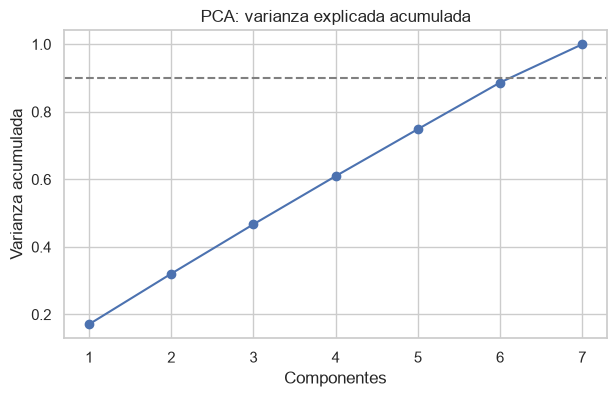

PC1   0.17
PC2   0.32
PC3   0.47
PC4   0.61
PC5   0.75
PC6   0.89
PC7   1.00
dtype: float64


In [15]:
num_pca = ['PreviousDemand', 'Temperature', 'Humidity', 'Hour_sin', 'Hour_cos', 'IsHoliday', 'IsWeekend']
X_pca = StandardScaler().fit_transform(df[num_pca].fillna(df[num_pca].median()))
pca = PCA().fit(X_pca)
var_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(.9, color='gray', ls='--'); plt.xlabel('Componentes'); plt.ylabel('Varianza acumulada')
plt.title('PCA: varianza explicada acumulada'); plt.show()
print(pd.Series(var_acum, index=[f'PC{i+1}' for i in range(len(var_acum))]).round(3))

**Decisión:** **no se aplica PCA**. La varianza está repartida de forma casi uniforme entre los componentes
(los predictores son prácticamente independientes entre sí), así que para retener el 90 % habría que conservar casi todos.
Con tan pocas variables no hay un problema de dimensionalidad, y PCA haría perder la interpretabilidad
(por ejemplo, saber cuánto pesa la demanda anterior).

La reducción que sí se hizo fue la del **conocimiento del negocio** (paso 3.1): de 19 columnas se pasó a
9 variables de entrada. Se conservan las variables climáticas aunque su relación sea débil, porque
el objetivo del negocio las menciona y los modelos no lineales podrían aprovechar interacciones.

## 3.8 Balanceo
**No aplica.** El balanceo de clases es para problemas de clasificación; este es un problema de regresión.

---
# 4. MODELAMIENTO Y EVALUACIÓN

## 4.1 División de los datos: 70 % entrenamiento / 30 % prueba

Como los datos son una **serie de tiempo**, la división se hace en **orden cronológico**: el 70 % más antiguo
para entrenar y el 30 % más reciente para probar. Una división aleatoria permitiría que el modelo "viera el futuro"
y daría métricas optimistas. Por la misma razón, la validación cruzada usa `TimeSeriesSplit`
(cada fold entrena con el pasado y valida con el período siguiente).

In [16]:
FEATURES_NUM = ['PreviousDemand', 'Temperature', 'Humidity', 'Hour_sin', 'Hour_cos']
FEATURES_BIN = ['IsHoliday', 'IsWeekend']
FEATURES_CAT = ['DayOfWeek', 'Month']
FEATURES = FEATURES_NUM + FEATURES_BIN + FEATURES_CAT
OBJETIVO = 'EnergyDemand'

corte = int(len(df) * 0.7)
train, test = df.iloc[:corte], df.iloc[corte:]
X_train, y_train = train[FEATURES], train[OBJETIVO]
X_test, y_test = test[FEATURES], test[OBJETIVO]

print(f'Entrenamiento: {len(train)} registros  ({train.DateTime.min():%d/%m/%Y} - {train.DateTime.max():%d/%m/%Y})')
print(f'Prueba       : {len(test)} registros  ({test.DateTime.min():%d/%m/%Y} - {test.DateTime.max():%d/%m/%Y})')

cv = TimeSeriesSplit(n_splits=5)

Entrenamiento: 1223 registros  (01/01/2023 - 28/02/2023)
Prueba       : 525 registros  (28/02/2023 - 25/03/2023)


### Preprocesamiento común (dentro del pipeline)
* Numéricas: imputación por mediana + estandarización (necesaria para KNN, SVR y la red neuronal).
* Binarias: imputación por la moda.
* Categóricas (`DayOfWeek`, `Month`): One Hot Encoding.

Para SVR y la red neuronal también se estandariza la **variable objetivo** (`TransformedTargetRegressor`),
porque trabajan mal cuando la salida está en cientos de MW.

In [17]:
def hacer_preprocesador(num=FEATURES_NUM):
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('esc', StandardScaler())]), num),
        ('bin', SimpleImputer(strategy='most_frequent'), FEATURES_BIN),
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT),
    ])

def hacer_pipeline(modelo, escalar_y=False, num=FEATURES_NUM):
    if escalar_y:
        modelo = TransformedTargetRegressor(regressor=modelo, transformer=StandardScaler())
    return Pipeline([('prep', hacer_preprocesador(num)), ('modelo', modelo)])

## 4.2 Justificación de la métrica de desempeño

Para ajustar los hiperparámetros se usa el **MAPE** (error porcentual absoluto medio):

* Es la métrica con la que se definió el **criterio de éxito** en la fase 1 (superar el 1,69 % de la línea base).
* Es porcentual, así que se interpreta igual en horas de alta y de baja demanda.
* La demanda nunca es cero (mínimo válido 300 MW), así que el MAPE no tiene problemas de división por cero.

Se reportan también MAE (en MW, fácil de entender para el área técnica), RMSE (castiga más los errores grandes,
que son los costosos) y R².

In [18]:
METRICA = 'neg_mean_absolute_percentage_error'

def metricas(y_real, y_pred):
    return {
        'MAE (MW)': mean_absolute_error(y_real, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_real, y_pred) * 100,
        'RMSE (MW)': np.sqrt(mean_squared_error(y_real, y_pred)),
        'R2': r2_score(y_real, y_pred),
    }

def ajustar(nombre, pipeline, grilla):
    gs = GridSearchCV(pipeline, grilla, cv=cv, scoring=METRICA, n_jobs=-1)
    gs.fit(X_train, y_train)
    print(f'{nombre:<22} MAPE CV = {-gs.best_score_*100:.3f} %   mejores: {gs.best_params_}')
    return gs

ajustes = {}

### Líneas base
Antes de entrenar, se calculan las dos referencias ingenuas del criterio de éxito, ahora sobre el set de prueba.

In [19]:
base_media = metricas(y_test, np.full(len(y_test), y_train.mean()))
base_anterior = metricas(y_test, X_test['PreviousDemand'])
pd.DataFrame({'Base: promedio': base_media, 'Base: hora anterior': base_anterior}).T

,MAE (MW),MAPE (%),RMSE (MW),R2
Base: promedio,97.17,10.08,140.33,-0.00
Base: hora anterior,15.28,1.68,19.15,0.98


## 4.3 Ajuste de hiperparámetros — 5 modelos de Machine Learning clásico

Todos con `GridSearchCV` sobre el 70 % de entrenamiento y validación cruzada `TimeSeriesSplit` de 5 folds.

| Modelo | Hiperparámetros ajustados |
|---|---|
| Regresión Ridge | `alpha` (regularización) |
| KNN | `n_neighbors`, `weights` |
| Árbol de decisión | `max_depth`, `min_samples_leaf` |
| SVR | `kernel`, `C`, `epsilon` |
| Red neuronal (MLP) | `hidden_layer_sizes`, `alpha` |

In [20]:
ajustes['Ridge'] = ajustar('Ridge', hacer_pipeline(Ridge()),
    {'modelo__alpha': [0.01, 0.1, 1, 10, 100]})

ajustes['KNN'] = ajustar('KNN', hacer_pipeline(KNeighborsRegressor()),
    {'modelo__n_neighbors': [3, 5, 10, 20, 40], 'modelo__weights': ['uniform', 'distance']})

ajustes['Árbol de decisión'] = ajustar('Árbol de decisión', hacer_pipeline(DecisionTreeRegressor(random_state=SEMILLA)),
    {'modelo__max_depth': [3, 5, 8, 12, None], 'modelo__min_samples_leaf': [1, 5, 20, 50]})

ajustes['SVR'] = ajustar('SVR', hacer_pipeline(SVR(), escalar_y=True),
    {'modelo__regressor__kernel': ['linear', 'rbf'],
     'modelo__regressor__C': [0.1, 1, 10],
     'modelo__regressor__epsilon': [0.01, 0.1]})

ajustes['Red neuronal (MLP)'] = ajustar('Red neuronal (MLP)',
    hacer_pipeline(MLPRegressor(max_iter=2000, early_stopping=True, random_state=SEMILLA), escalar_y=True),
    {'modelo__regressor__hidden_layer_sizes': [(16,), (32,), (32, 16)],
     'modelo__regressor__alpha': [0.0001, 0.01, 1]})

Ridge                  MAPE CV = 1.712 %   mejores: {'modelo__alpha': 1}


KNN                    MAPE CV = 4.191 %   mejores: {'modelo__n_neighbors': 10, 'modelo__weights': 'distance'}


Árbol de decisión      MAPE CV = 2.018 %   mejores: {'modelo__max_depth': 5, 'modelo__min_samples_leaf': 5}


SVR                    MAPE CV = 1.714 %   mejores: {'modelo__regressor__C': 1, 'modelo__regressor__epsilon': 0.1, 'modelo__regressor__kernel': 'linear'}


Red neuronal (MLP)     MAPE CV = 2.722 %   mejores: {'modelo__regressor__alpha': 1, 'modelo__regressor__hidden_layer_sizes': (32, 16)}


## 4.4 Ajuste de hiperparámetros — 3 modelos de ensamble

| Ensamble | Tipo | Configuración |
|---|---|---|
| Voting Regressor | Votación | Promedia las predicciones de los modelos clásicos ya ajustados (Ridge, SVR y MLP) |
| Random Forest | Bagging | Se ajustan `n_estimators`, `max_depth`, `min_samples_leaf` |
| Gradient Boosting | Boosting | Se ajustan `n_estimators`, `learning_rate`, `max_depth` |

In [21]:
ajustes['Random Forest (bagging)'] = ajustar('Random Forest (bagging)',
    hacer_pipeline(RandomForestRegressor(random_state=SEMILLA, n_jobs=-1)),
    {'modelo__n_estimators': [200, 400], 'modelo__max_depth': [5, 10, None], 'modelo__min_samples_leaf': [1, 5, 20]})

ajustes['Gradient Boosting (boosting)'] = ajustar('Gradient Boosting (boosting)',
    hacer_pipeline(GradientBoostingRegressor(random_state=SEMILLA)),
    {'modelo__n_estimators': [100, 300], 'modelo__learning_rate': [0.01, 0.05, 0.1], 'modelo__max_depth': [2, 3, 5]})

Random Forest (bagging) MAPE CV = 1.776 %   mejores: {'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 400}


Gradient Boosting (boosting) MAPE CV = 1.773 %   mejores: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 2, 'modelo__n_estimators': 300}


In [22]:
# Voting: usa los modelos clásicos ya ajustados (cada uno con su propio pipeline)
voting = VotingRegressor([
    ('ridge', ajustes['Ridge'].best_estimator_),
    ('svr', ajustes['SVR'].best_estimator_),
    ('mlp', ajustes['Red neuronal (MLP)'].best_estimator_),
])
ajustes['Voting (votación)'] = ajustar('Voting (votación)', voting,
    {'weights': [None, [2, 1, 1], [1, 2, 1], [1, 1, 2]]})

Voting (votación)      MAPE CV = 1.757 %   mejores: {'weights': [2, 1, 1]}


In [23]:
resumen_cv = pd.DataFrame({
    'MAPE CV (%)': {n: -g.best_score_ * 100 for n, g in ajustes.items()},
    'Desv. CV (%)': {n: g.cv_results_['std_test_score'][g.best_index_] * 100 for n, g in ajustes.items()},
}).sort_values('MAPE CV (%)')
resumen_cv

,MAPE CV (%),Desv. CV (%)
Ridge,1.71,0.03
SVR,1.71,0.03
Voting (votación),1.76,0.18
Gradient Boosting (boosting),1.77,0.19
Random Forest (bagging),1.78,0.13
Árbol de decisión,2.02,0.23
Red neuronal (MLP),2.72,1.64
KNN,4.19,0.38


## 4.5 Medida de calidad del modelo — evaluación con el set de prueba

Cada modelo, con sus mejores hiperparámetros, se evalúa sobre el 30 % de prueba, que nunca participó en el ajuste.

In [24]:
resultados = {'Base: promedio': base_media, 'Base: hora anterior': base_anterior}
predicciones = {}
for nombre, gs in ajustes.items():
    pred = gs.best_estimator_.predict(X_test)
    predicciones[nombre] = pred
    resultados[nombre] = metricas(y_test, pred)

tabla = pd.DataFrame(resultados).T.sort_values('MAPE (%)')
tabla['Mejor que hora anterior'] = np.where(tabla['MAPE (%)'] < base_anterior['MAPE (%)'], 'Sí', 'No')
tabla

,MAE (MW),MAPE (%),RMSE (MW),R2,Mejor que hora anterior
Base: hora anterior,15.28,1.68,19.15,0.98,No
SVR,15.37,1.68,19.08,0.98,No
Gradient Boosting (boosting),15.44,1.69,19.12,0.98,No
Ridge,15.46,1.69,19.13,0.98,No
Random Forest (bagging),16.22,1.76,20.77,0.98,No
Voting (votación),16.16,1.78,19.99,0.98,No
Árbol de decisión,17.30,1.85,23.26,0.97,No
Red neuronal (MLP),26.29,2.95,31.51,0.95,No
KNN,35.49,3.70,49.46,0.88,No
Base: promedio,97.17,10.08,140.33,-0.00,No


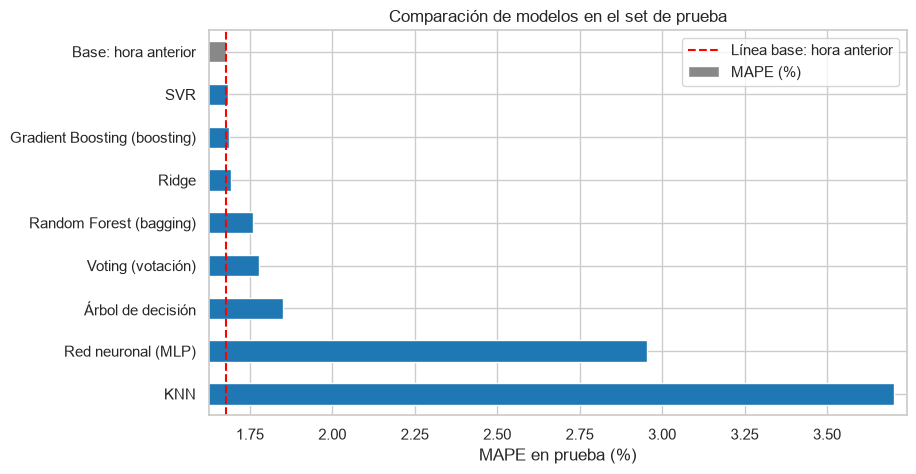

In [25]:
modelos = tabla.drop(['Base: promedio']).copy()
colores = ['#888' if n.startswith('Base') else '#1f77b4' for n in modelos.index]
ax = modelos['MAPE (%)'].plot.barh(figsize=(9, 5), color=colores)
ax.axvline(base_anterior['MAPE (%)'], color='red', ls='--', label='Línea base: hora anterior')
ax.invert_yaxis(); ax.set_xlabel('MAPE en prueba (%)'); ax.legend()
ax.set_xlim(modelos['MAPE (%)'].min() * 0.97, modelos['MAPE (%)'].max() * 1.01)
plt.title('Comparación de modelos en el set de prueba'); plt.show()

## 4.6 Selección del modelo con mejor desempeño

In [26]:
mejor_nombre = tabla.drop(['Base: promedio', 'Base: hora anterior']).index[0]
mejor = ajustes[mejor_nombre].best_estimator_
print('Mejor modelo:', mejor_nombre)
print('Hiperparámetros:', ajustes[mejor_nombre].best_params_)
pd.Series(resultados[mejor_nombre]).round(4)

Mejor modelo: SVR
Hiperparámetros: {'modelo__regressor__C': 1, 'modelo__regressor__epsilon': 0.1, 'modelo__regressor__kernel': 'linear'}


MAE (MW)    15.37
MAPE (%)     1.68
RMSE (MW)   19.08
R2           0.98
dtype: float64

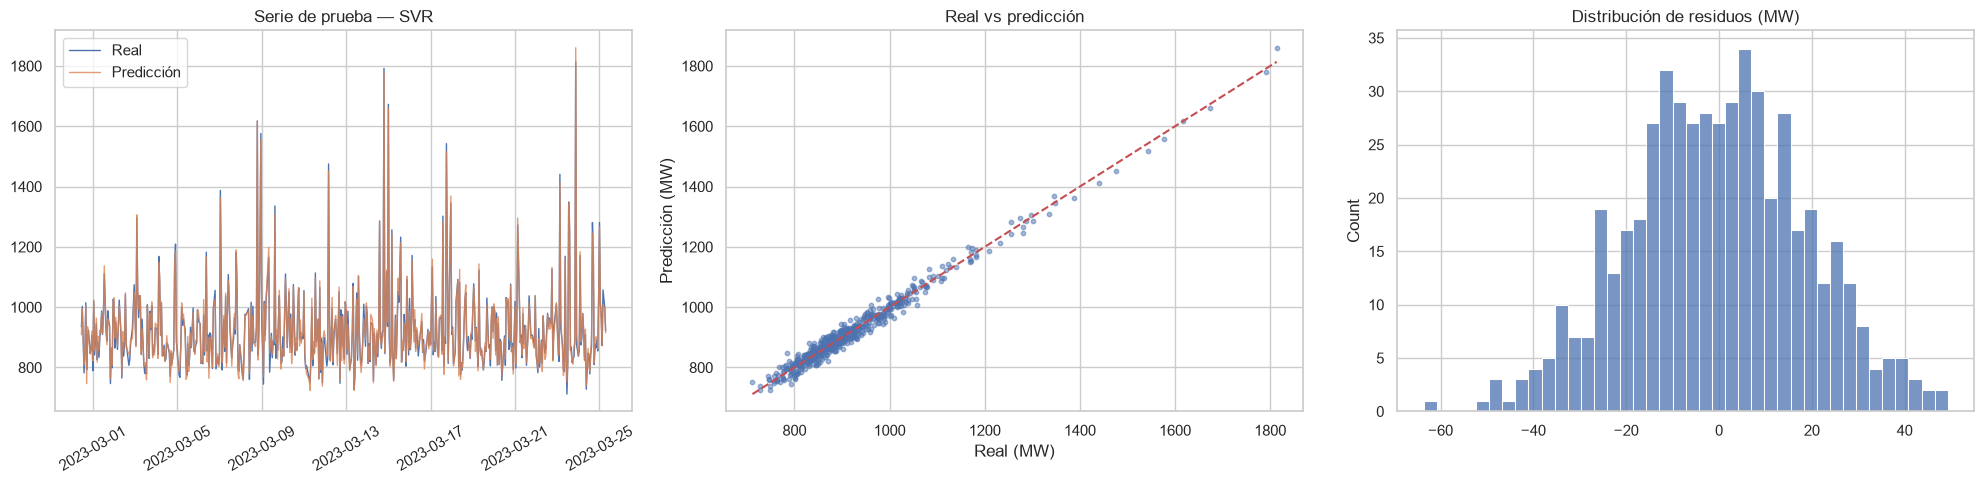

In [27]:
pred = predicciones[mejor_nombre]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(test['DateTime'], y_test.values, label='Real', lw=1)
axes[0].plot(test['DateTime'], pred, label='Predicción', lw=1, alpha=.8)
axes[0].set_title(f'Serie de prueba — {mejor_nombre}'); axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

axes[1].scatter(y_test, pred, s=10, alpha=.5)
lim = [y_test.min(), y_test.max()]
axes[1].plot(lim, lim, 'r--'); axes[1].set_xlabel('Real (MW)'); axes[1].set_ylabel('Predicción (MW)')
axes[1].set_title('Real vs predicción')

sns.histplot(y_test.values - pred, bins=40, ax=axes[2])
axes[2].set_title('Distribución de residuos (MW)')
plt.tight_layout(); plt.show()

### Importancia de las variables
Se mide con **importancia por permutación** sobre el set de prueba: cuánto empeora el MAPE si se desordena cada variable.

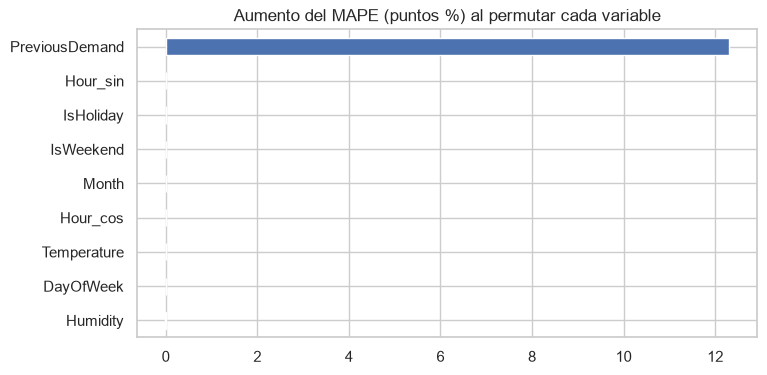

PreviousDemand   12.30
Hour_sin          0.00
IsHoliday        -0.00
IsWeekend        -0.00
Month            -0.00
Hour_cos         -0.00
Temperature      -0.00
DayOfWeek        -0.00
Humidity         -0.01
dtype: float64

In [28]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(mejor, X_test, y_test, scoring=METRICA, n_repeats=20, random_state=SEMILLA)
importancias = pd.Series(imp.importances_mean * 100, index=FEATURES).sort_values()
importancias.plot.barh(figsize=(8, 4), title='Aumento del MAPE (puntos %) al permutar cada variable')
plt.show()
importancias.sort_values(ascending=False).round(4)

## 4.7 Escenario complementario: pronóstico sin la demanda de la hora anterior

La importancia por permutación muestra que el modelo prácticamente solo usa `PreviousDemand`. Para comprobar si las
variables climáticas y de calendario tienen valor por sí mismas, se repite el ejercicio **sin** esa variable.
Es el caso real de un pronóstico con un día de anticipación (*day-ahead*), cuando todavía no se conoce la demanda de la hora previa.
Se usan los mismos hiperparámetros encontrados en 4.3 y 4.4, cambiando solo las variables de entrada.

In [29]:
FEATURES_NUM_SR = [c for c in FEATURES_NUM if c != 'PreviousDemand']
FEATURES_SR = FEATURES_NUM_SR + FEATURES_BIN + FEATURES_CAT

def sin_rezago(gs):
    """Mismo modelo e hiperparámetros, pero con un preprocesador que no usa PreviousDemand."""
    pipe = clone(gs.best_estimator_)
    if isinstance(pipe, VotingRegressor):
        pipe.estimators = [(n, sin_rezago_pipe(p)) for n, p in pipe.estimators]
        return pipe
    return sin_rezago_pipe(pipe)

def sin_rezago_pipe(pipe):
    pipe = clone(pipe)
    pipe.steps[0] = ('prep', hacer_preprocesador(FEATURES_NUM_SR))
    return pipe

res_sr = {'Base: promedio': metricas(y_test, np.full(len(y_test), y_train.mean()))}
for nombre, gs in ajustes.items():
    m = sin_rezago(gs).fit(X_train[FEATURES_SR], y_train)
    res_sr[nombre] = metricas(y_test, m.predict(X_test[FEATURES_SR]))

tabla_sr = pd.DataFrame(res_sr).T.sort_values('MAPE (%)')
tabla_sr

,MAE (MW),MAPE (%),RMSE (MW),R2
Gradient Boosting (boosting),40.63,4.32,63.60,0.79
Random Forest (bagging),42.00,4.46,69.63,0.75
Árbol de decisión,47.14,4.99,72.11,0.74
KNN,63.55,6.42,99.39,0.50
Red neuronal (MLP),72.16,7.94,93.36,0.56
Voting (votación),77.25,8.03,115.44,0.32
SVR,87.67,8.63,142.35,-0.03
Ridge,95.29,9.83,140.63,-0.01
Base: promedio,97.17,10.08,140.33,-0.00


### Conclusiones

**Sobre los datos y la preparación**
* De 2.000 registros quedaron 1.748 válidos (87,4 %). Se eliminaron 8 demandas imposibles, 48 registros de otros países
  y 196 registros sin `PreviousDemand`. Las temperaturas nulas o imposibles se recuperaron casi todas desde `Temperature_F`.
* Las columnas `Hour`, `DayOfWeek` y `Month` estaban corrompidas y se reconstruyeron desde `DateTime`.
  `PeakHourFlag` se eliminó por fuga de información.
* La temperatura tiene una relación **no lineal en forma de U** con la demanda que la correlación de Pearson no detecta
  y la información mutua sí.

**Sobre los modelos (escenario principal, con `PreviousDemand`)**
* Los mejores modelos fueron **SVR con kernel lineal**, **Gradient Boosting** y **Ridge**, con un MAPE de ≈ 1,68–1,69 % en prueba
  y R² ≈ 0,98. El modelo seleccionado es **SVR** (MAPE 1,684 %, MAE 15,4 MW).
* Este resultado **cumple el criterio de éxito** definido en la fase 1 (MAPE < 1,69 %), pero hay que leerlo con honestidad:
  sobre este mismo set de prueba, la regla ingenua "la próxima hora será igual a la anterior" obtiene 1,677 %.
  Ningún modelo la supera de forma significativa: la diferencia está en la segunda cifra decimal.
* La importancia por permutación lo explica: el modelo solo usa `PreviousDemand`. La demanda de la hora anterior ya
  "contiene" el efecto del clima y del calendario, y lo que cambia de una hora a la siguiente (± 19 MW en promedio)
  no está relacionado con ninguna de las variables disponibles: se comporta como ruido.
* KNN y la red neuronal fueron los peores: con tan pocos datos y una relación casi lineal, su flexibilidad no ayuda y
  sí añade varianza. Los ensambles (Random Forest, Voting) no mejoraron a los modelos lineales.

**Sobre el escenario sin la demanda anterior (4.7)**
* Sin `PreviousDemand`, la regresión lineal (Ridge) prácticamente no mejora a predecir el promedio (≈ 10 % de MAPE),
  mientras que **Gradient Boosting y Random Forest bajan el error a ≈ 4,3–4,5 %**. Ahí sí se ve el aporte de las variables
  climáticas y el valor de los modelos no lineales, porque son capaces de aprender la curva en U de la temperatura.

**Recomendación para el negocio:** para el pronóstico de la próxima hora, el modelo desplegado es confiable
(error medio ≈ 15 MW, 1,7 %), pero su valor agregado frente a usar la demanda anterior es marginal. Para pronósticos con
más anticipación (cuando no se conoce la demanda previa) conviene un ensamble tipo Gradient Boosting con variables
climáticas. Para mejorar el pronóstico horario harían falta variables que hoy no están en el dataset, como más rezagos
(demanda de hace 24 horas y de hace una semana) o eventos especiales.

---
# 5. DESPLIEGUE

El modelo seleccionado se reentrena con **todos** los datos limpios (entrenamiento + prueba) para aprovechar la información
más reciente, y se guarda con `joblib` junto con sus metadatos. Luego se publica como aplicación web con **Streamlit**.

Pasos para publicarlo en **Streamlit Community Cloud** (gratis):
1. Ejecutar este cuaderno completo. Se genera la carpeta `despliegue/` con `app.py`, `requirements.txt`,
   `modelo_demanda.joblib` y `metadatos_modelo.json` (y en Colab se descarga como `despliegue.zip`).
2. Crear un repositorio en GitHub y subir esos cuatro archivos.
3. Entrar a https://share.streamlit.io, iniciar sesión con GitHub, **Create app**, elegir el repositorio y `app.py` como archivo principal.
4. En un par de minutos queda una URL pública del tipo `https://<nombre>.streamlit.app`.

In [30]:
os.makedirs('despliegue', exist_ok=True)

modelo_final = ajustes[mejor_nombre].best_estimator_
modelo_final.fit(df[FEATURES], df[OBJETIVO])
joblib.dump(modelo_final, 'despliegue/modelo_demanda.joblib')

metadatos = {
    'modelo': mejor_nombre,
    'hiperparametros': {k: str(v) for k, v in ajustes[mejor_nombre].best_params_.items()},
    'metricas_prueba': {k: round(float(v), 4) for k, v in resultados[mejor_nombre].items()},
    'linea_base_hora_anterior': {k: round(float(v), 4) for k, v in base_anterior.items()},
    'features': FEATURES,
    'registros_entrenamiento': int(len(df)),
    'periodo': [f'{df.DateTime.min():%Y-%m-%d}', f'{df.DateTime.max():%Y-%m-%d}'],
    'scikit_learn': sklearn.__version__,
}
with open('despliegue/metadatos_modelo.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

with open('despliegue/requirements.txt', 'w') as f:
    f.write(f'streamlit\nscikit-learn=={sklearn.__version__}\npandas\nnumpy\njoblib\n')

print(json.dumps(metadatos, ensure_ascii=False, indent=2))

{
  "modelo": "SVR",
  "hiperparametros": {
    "modelo__regressor__C": "1",
    "modelo__regressor__epsilon": "0.1",
    "modelo__regressor__kernel": "linear"
  },
  "metricas_prueba": {
    "MAE (MW)": 15.3733,
    "MAPE (%)": 1.684,
    "RMSE (MW)": 19.0815,
    "R2": 0.9815
  },
  "linea_base_hora_anterior": {
    "MAE (MW)": 15.2848,
    "MAPE (%)": 1.6771,
    "RMSE (MW)": 19.1527,
    "R2": 0.9813
  },
  "features": [
    "PreviousDemand",
    "Temperature",
    "Humidity",
    "Hour_sin",
    "Hour_cos",
    "IsHoliday",
    "IsWeekend",
    "DayOfWeek",
    "Month"
  ],
  "registros_entrenamiento": 1748,
  "periodo": [
    "2023-01-01",
    "2023-03-25"
  ],
  "scikit_learn": "1.9.1"
}


### Aplicación web (`app.py`)

In [31]:
%%writefile despliegue/app.py
import json
from datetime import date, time, datetime

import joblib
import numpy as np
import pandas as pd
import streamlit as st

st.set_page_config(page_title='Pronóstico de demanda eléctrica', page_icon='⚡', layout='centered')


@st.cache_resource
def cargar():
    modelo = joblib.load('modelo_demanda.joblib')
    with open('metadatos_modelo.json', encoding='utf-8') as f:
        meta = json.load(f)
    return modelo, meta


def crear_variables(fecha_hora, demanda_anterior, temperatura, humedad, festivo):
    """Mismas variables que en el entrenamiento (ver crear_variables del cuaderno)."""
    hora = fecha_hora.hour
    dia = fecha_hora.weekday()
    return pd.DataFrame([{
        'PreviousDemand': demanda_anterior,
        'Temperature': temperatura,
        'Humidity': humedad,
        'Hour_sin': np.sin(2 * np.pi * hora / 24),
        'Hour_cos': np.cos(2 * np.pi * hora / 24),
        'IsHoliday': int(festivo),
        'IsWeekend': int(dia >= 5),
        'DayOfWeek': dia,
        'Month': fecha_hora.month,
    }])


modelo, meta = cargar()

st.title('⚡ Pronóstico de demanda eléctrica horaria')
st.caption('Trabajo Final de Machine Learning · Sofía Castañeda Arias y James Jair Olarte López')

with st.form('entrada'):
    c1, c2 = st.columns(2)
    fecha = c1.date_input('Fecha a pronosticar', date(2023, 3, 1))
    hora = c2.time_input('Hora', time(18, 0), step=3600)
    demanda_anterior = st.number_input('Demanda de la hora anterior (MW)', 300.0, 2000.0, 900.0, step=10.0)
    c3, c4 = st.columns(2)
    temperatura = c3.slider('Temperatura pronosticada (°C)', -5.0, 45.0, 20.0, 0.5)
    humedad = c4.slider('Humedad relativa (%)', 0.0, 100.0, 60.0, 1.0)
    festivo = st.checkbox('Es día festivo')
    enviar = st.form_submit_button('Pronosticar', type='primary')

if enviar:
    fecha_hora = datetime.combine(fecha, hora)
    X = crear_variables(fecha_hora, demanda_anterior, temperatura, humedad, festivo)
    pred = float(modelo.predict(X)[0])
    mae = meta['metricas_prueba']['MAE (MW)']
    st.metric('Demanda estimada', f'{pred:,.1f} MW', f'{pred - demanda_anterior:+,.1f} MW vs hora anterior')
    st.write(f'Rango esperado (± MAE de prueba): **{pred - mae:,.0f} – {pred + mae:,.0f} MW**')

with st.expander('Sobre el modelo'):
    st.write(f"**Modelo:** {meta['modelo']}")
    st.write(f"**Entrenado con** {meta['registros_entrenamiento']} registros horarios "
             f"({meta['periodo'][0]} a {meta['periodo'][1]}).")
    st.write('**Métricas en el set de prueba:**')
    st.table(pd.DataFrame({'Modelo': meta['metricas_prueba'],
                           'Línea base (hora anterior)': meta['linea_base_hora_anterior']}))

Writing despliegue/app.py


### Prueba local del modelo guardado
Se carga el archivo `.joblib` tal como lo hará la aplicación y se hace una predicción de ejemplo.

In [32]:
modelo_cargado = joblib.load('despliegue/modelo_demanda.joblib')
ejemplo = crear_variables(pd.DataFrame({
    'DateTime': [pd.Timestamp('2023-03-20 18:00')],
    'PreviousDemand': [950.0], 'Temperature': [22.0], 'Humidity': [65.0], 'IsHoliday': [1],
}))
print(f"Demanda estimada: {modelo_cargado.predict(ejemplo[FEATURES])[0]:,.1f} MW")

Demanda estimada: 951.0 MW


### Descargar los archivos (solo en Colab)

In [33]:
import shutil
shutil.make_archive('despliegue', 'zip', 'despliegue')
try:
    from google.colab import files
    files.download('despliegue.zip')
except ImportError:
    print('Fuera de Colab: los archivos quedaron en la carpeta despliegue/ y en despliegue.zip')

Fuera de Colab: los archivos quedaron en la carpeta despliegue/ y en despliegue.zip


### Opcional: probar la app desde Colab sin GitHub
Ejecute la siguiente celda en Colab. Muestra una URL pública temporal (válida mientras la sesión de Colab esté activa)
y una contraseña, que es la IP que se imprime en la primera línea.

In [34]:
# Descomente para ejecutar en Colab:
# !pip -q install streamlit
# !cd despliegue && curl -s https://loca.lt/mytunnelpassword && echo && (streamlit run app.py --server.port 8501 &>/dev/null &) && npx -y localtunnel --port 8501